In [2]:
# 생선의 길이
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]

# 생선의 무게
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

In [3]:
import matplotlib.pyplot as plt

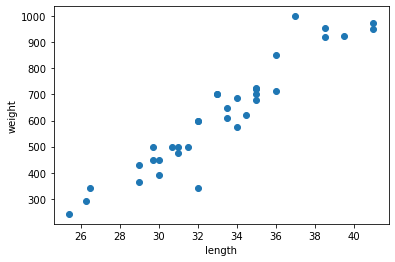

In [4]:
# 산점도 그리기
plt.scatter(bream_length, bream_weight)

# x축: 길이(x축 이름을 length)
plt.xlabel('length')

# y축: 무게(y축 이름을 weight)
plt.ylabel('weight')


plt.show()
# 산점도 결과 선형 그래프 형태인 것을 확인

In [5]:
# 빙어 데이터 준비
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

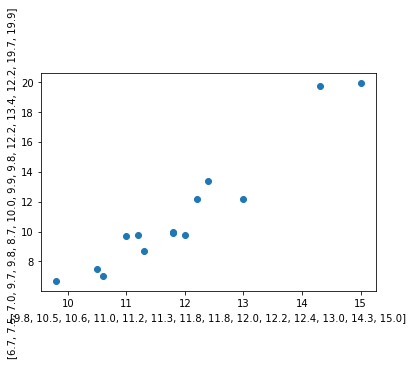

In [6]:
plt.scatter(smelt_length, smelt_weight)
plt.xlabel(smelt_length)
plt.ylabel(smelt_weight)
plt.show()
# 산점도 결과 선형 그래프 형태인 것을 확인

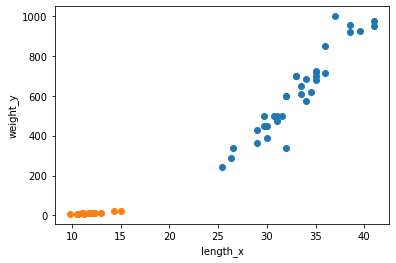

In [8]:
# 두개의 데이터를 한 그래프에서 나타내기
plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)
plt.xlabel('length_x')
plt.ylabel('weight_y')
plt.show()

In [9]:
# k-최근접 이웃 알고르짐을 사용하기 위해 데이터 합치기
length = bream_length + smelt_length
weight = bream_weight + smelt_weight

In [10]:
# 사이킷런: 머신러닝 패키지
# 2차원 리스트 필요
# 현재 length, weight 데이터를 2차원 배열로 바꾸는 작업이 필요(-> zip함수로 해결)
fish_data = [[l, w] for l, w in zip(length, weight)]

In [11]:
# 데이터 확인
print(fish_data)

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0], [29.7, 450.0], [29.7, 500.0], [30.0, 390.0], [30.0, 450.0], [30.7, 500.0], [31.0, 475.0], [31.0, 500.0], [31.5, 500.0], [32.0, 340.0], [32.0, 600.0], [32.0, 600.0], [33.0, 700.0], [33.0, 700.0], [33.5, 610.0], [33.5, 650.0], [34.0, 575.0], [34.0, 685.0], [34.5, 620.0], [35.0, 680.0], [35.0, 700.0], [35.0, 725.0], [35.0, 720.0], [36.0, 714.0], [36.0, 850.0], [37.0, 1000.0], [38.5, 920.0], [38.5, 955.0], [39.5, 925.0], [41.0, 975.0], [41.0, 950.0], [9.8, 6.7], [10.5, 7.5], [10.6, 7.0], [11.0, 9.7], [11.2, 9.8], [11.3, 8.7], [11.8, 10.0], [11.8, 9.9], [12.0, 9.8], [12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]


In [13]:
# 정답 데이터 준비
# 도미:1(찾으려는 대상), 빙어:0(그 외의 대상)으로 표기
fish_target = [1]*35 + [0]*14
print(fish_target)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [15]:
from sklearn.neighbors import KNeighborsClassifier

In [16]:
# KNeighborsClassifier 클래스 객체 생성
kn = KNeighborsClassifier()

In [17]:
# 두가지 데이터로 도미를 찾기 위한 기준을 학습: fit()
kn.fit(fish_data, fish_target)

KNeighborsClassifier()

In [19]:
# 정확도(score) 계산
# 0과 1 사이의 값 출력
kn.score(fish_data, fish_target)

1.0

In [29]:
# 새로운 입력값에 대해 예측해보기
kn.predict([[30, 600]])
# predict = kn.predict([[30, 600]])

# if predict == 1:
#     print("도미입니다")
# else:
#     print("빙어입니다")


array([1])

In [58]:
# K-최근접 이웃 알고리즘은 가장 가까운 데이터를 참고하여 
# 새로운 데이터를 도미인지 빙어인지 구분
# 참고 데이터를 49개로 적용한 kn49모델
kn9 = KNeighborsClassifier(n_neighbors=18)

In [59]:
kn9.fit(fish_data, fish_target)
kn9.score(fish_data, fish_target)

0.9795918367346939

In [68]:
# 정확도가 1이하로 내려가는 n_neighbors를 찾기
kn = KNeighborsClassifier()
kn.fit(fish_data, fish_target)

for n in range(5, 50):
    # k-최근접 이웃 갯수 설정
    kn.n_neighbors = n
    
    # 점수 계산
    score = kn.score(fish_data, fish_target)
    
    # 100% 정확도에 미치지 못하는 이웃 개수 출력
    if score < 1:
#         print(n, score)
        print("이웃 {}개일 때부터 정확도가 1이하로 떨어지며, 정확도 점수는 {}입니다".format(n, score)
)
        break

18 0.9795918367346939
이웃 18개일 때부터 정확도가 1이하로 떨어지며, 정확도 점수는 0.9795918367346939입니다
